# Image Alignment & Calibration

## Import Libraries

In [58]:
import os, sys, importlib
import cv2, numpy as np
import matplotlib.pyplot as plt

# Make the shared module importable regardless of the kernel CWD.
def _find_project_root():
    d = os.path.abspath(os.getcwd())
    for _ in range(8):
        if os.path.exists(os.path.join(d, "image_pipeline.py")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            return None
        d = parent
    return None

_PROJECT_ROOT = _find_project_root()
if _PROJECT_ROOT and _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)

# Single source of truth: the shared image_pipeline module (Student 1 -> Student 2).
import image_pipeline
importlib.reload(image_pipeline)
from image_pipeline import (
    quick_corner_check,
    order_points,
    compute_destination,
    align_image,
    process_from_folder,
    align_from_source,   # read a file + (optionally) S1 preprocess + align
    detection_input,     # THE function the detector must be fed with
    save_aligned,
    load_student1_functions,
    student2_from_student1_array,   # S1 preprocess_image  -> aligned array
    student2_from_student1_bytes,   # S1 process_image_from_bytes -> aligned array
    student2_from_student1_video,   # S1 process_full_video_backend -> aligned video bytes
)

print("OpenCV Version:", cv2.__version__)
print("ALIGN_TARGET  :", image_pipeline.ALIGN_TARGET, "px (longest side of the aligned board)")
print("NumPy Version:", np.__version__)


OpenCV Version: 4.8.1
NumPy Version: 1.23.5


## Set Dataset Path

In [57]:
USE_RAW_ROTATION = True   # True = demo reads raw PCB_DATASET/rotation; False = reads Preprocessed_Dataset

if USE_RAW_ROTATION:
    input_folder = "../PCB_DATASET/rotation"
else:
    input_folder = "../Preprocessed_Dataset"

reference_folder = "../PCB_DATASET/PCB_USED"

# Student 2 keeps everything IN MEMORY (no file writes). This folder is used
# ONLY when the batch step's SAVE_OUTPUT flag is set to True (for inspection).
output_folder = "../Calibrated_Dataset"   # one folder, always (the old USE_GRAYSCALE
                                          # branch wrote to Calibrated_Dataset_no_gray, which
                                          # nothing downstream ever read)

print("USE_RAW_ROTATION:", USE_RAW_ROTATION)
print("Input:", input_folder)
print("Reference:", reference_folder)
print("Output (only if SAVE_OUTPUT=True):", output_folder)


USE_GRAYSCALE: False
USE_RAW_ROTATION: True
Input: ../PCB_DATASET/rotation
Reference: ../PCB_DATASET/PCB_USED
Output (only if SAVE_OUTPUT=True): ../Calibrated_Dataset_no_gray


## Load Dataset

In [34]:
classes = [
    folder for folder in os.listdir(input_folder)
    if os.path.isdir(os.path.join(input_folder, folder))
]

print("Classes:", classes)

images = []

for cls in classes:
    class_path = os.path.join(input_folder, cls)

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    for file in files:
        images.append((cls, os.path.join(class_path, file)))

print("Total Images:", len(images))


Classes: ['Missing_hole_rotation', 'Mouse_bite_rotation', 'Open_circuit_rotation', 'Short_rotation', 'Spurious_copper_rotation', 'Spur_rotation']
Total Images: 693


### Select Sample Image

In [35]:
def _quick_corner_check(img):
    """True if `img` contains a clean 4-corner PCB boundary (from image_pipeline)."""
    return quick_corner_check(img)


sample_cls, sample_path = images[0]
sample_image = cv2.imread(sample_path)

for cls, path in images:
    candidate = cv2.imread(path)
    if candidate is not None and _quick_corner_check(candidate):
        sample_cls, sample_path = cls, path
        sample_image = candidate
        break

print("Class:", sample_cls)
print("Image:", sample_path)


Class: Missing_hole_rotation
Image: ../PCB_DATASET/rotation\Missing_hole_rotation\01_missing_hole_01.jpg


## Grayscale & Edge Detection (Demo)

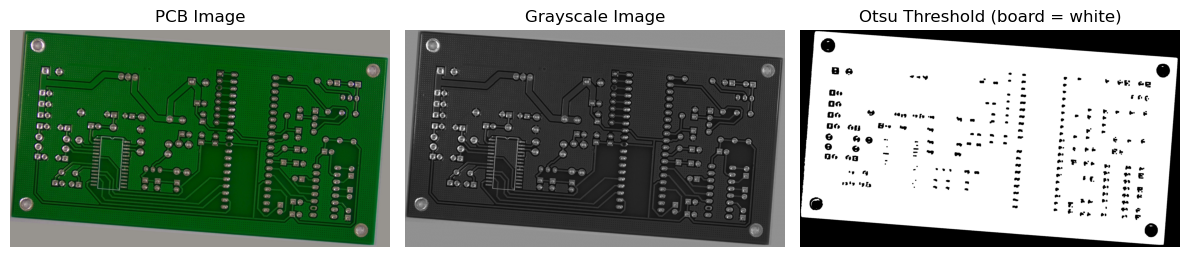

In [59]:
sample_gray = cv2.cvtColor(sample_image, cv2.COLOR_BGR2GRAY)
sample_blurred = cv2.GaussianBlur(sample_gray, (5, 5), 0)
_, sample_thresh = cv2.threshold(sample_blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
sample_thresh = cv2.morphologyEx(sample_thresh, cv2.MORPH_CLOSE,
                                 cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9)))

plt.figure(figsize=(12, 4))
for i, (img, title, cmap) in enumerate([
    (cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB), "PCB Image", None),
    (sample_gray, "Grayscale Image", "gray"),
    (sample_thresh, "Otsu Threshold (board = white)", "gray"),
]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()


## Contour Detection (Demo)

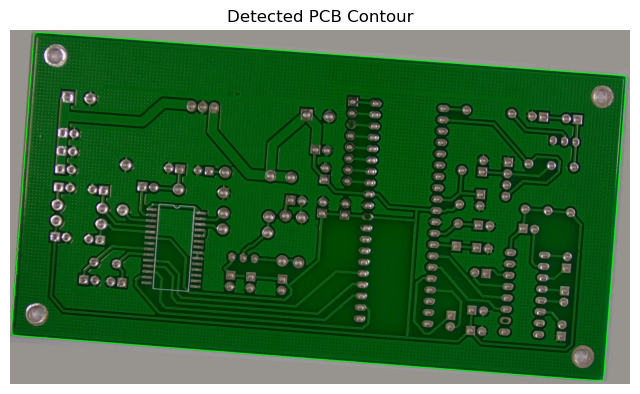

In [60]:
sample_contours, _ = cv2.findContours(sample_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
sample_largest_contour = max(sample_contours, key=cv2.contourArea)

contour_demo = sample_image.copy()
cv2.drawContours(contour_demo, [sample_largest_contour], -1, (0, 255, 0), 3)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(contour_demo, cv2.COLOR_BGR2RGB))
plt.title("Detected PCB Contour")
plt.axis("off")
plt.show()


## Corner Detection (Demo)

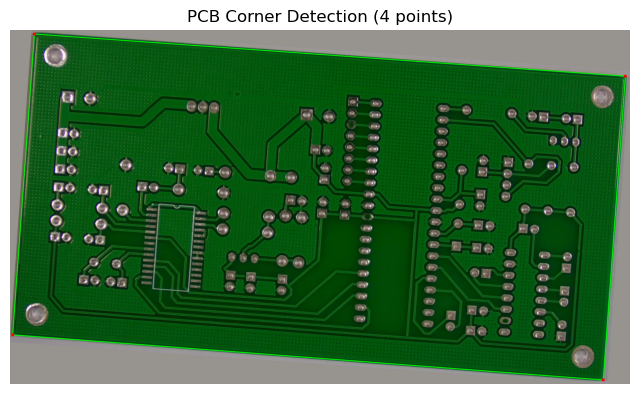

In [61]:
sample_perimeter = cv2.arcLength(sample_largest_contour, True)
sample_approx = cv2.approxPolyDP(sample_largest_contour, 0.02 * sample_perimeter, True)

corner_demo = sample_image.copy()
cv2.drawContours(corner_demo, [sample_approx], -1, (0, 255, 0), 3)
for x, y in sample_approx[:, 0]:
    cv2.circle(corner_demo, (x, y), 8, (0, 0, 255), -1)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(corner_demo, cv2.COLOR_BGR2RGB))
plt.title(f"PCB Corner Detection ({len(sample_approx)} points)")
plt.axis("off")
plt.show()


## Corner Ordering (Demo)

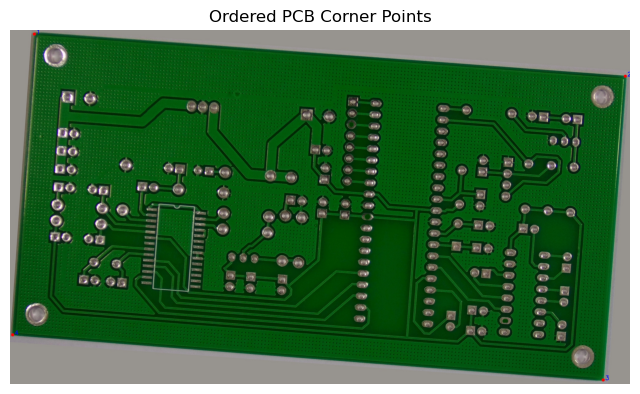

In [62]:
# order_points / compute_destination come from image_pipeline (single source of truth).
if len(sample_approx) == 4:
    sample_ordered = order_points(sample_approx.reshape(4, 2))
    order_demo = sample_image.copy()
    for i, (x, y) in enumerate(sample_ordered.astype(int)):
        cv2.circle(order_demo, (x, y), 8, (0, 0, 255), -1)
        cv2.putText(order_demo, str(i + 1), (x + 10, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(order_demo, cv2.COLOR_BGR2RGB))
    plt.title("Ordered PCB Corner Points")
    plt.axis("off")
    plt.show()
else:
    print("Sample image did not resolve to exactly 4 corners:", len(sample_approx))


## Perspective Transformation (Demo)

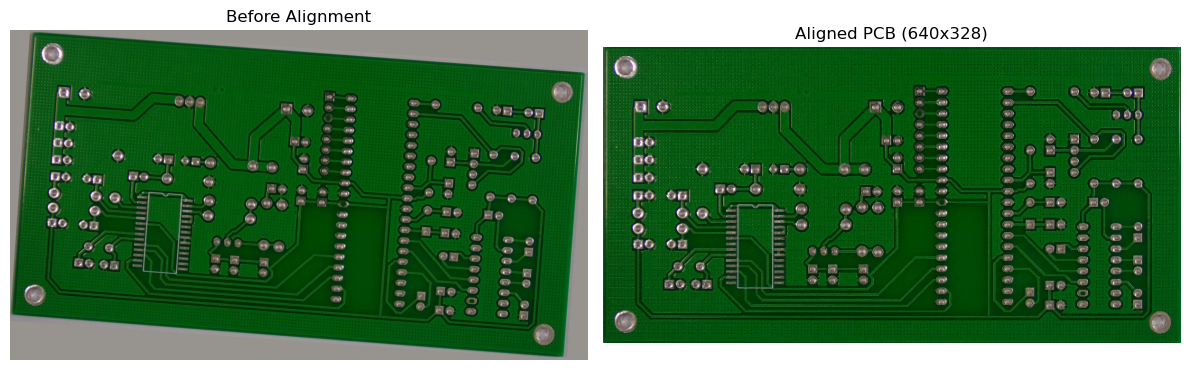

In [63]:
sample_aligned = None
if len(sample_approx) == 4:
    sample_ordered = order_points(sample_approx.reshape(4, 2))
    sample_dst, sample_w, sample_h = compute_destination(sample_ordered)
    matrix = cv2.getPerspectiveTransform(sample_ordered, sample_dst)
    sample_aligned = cv2.warpPerspective(sample_image, matrix, (sample_w, sample_h))

    plt.figure(figsize=(12, 5))
    for i, (img, title) in enumerate([
        (cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB), "Before Alignment"),
        (cv2.cvtColor(sample_aligned, cv2.COLOR_BGR2RGB), f"Aligned PCB ({sample_w}x{sample_h})"),
    ]):
        plt.subplot(1, 2, i + 1)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


### Full Alignment Pipeline (Demo)

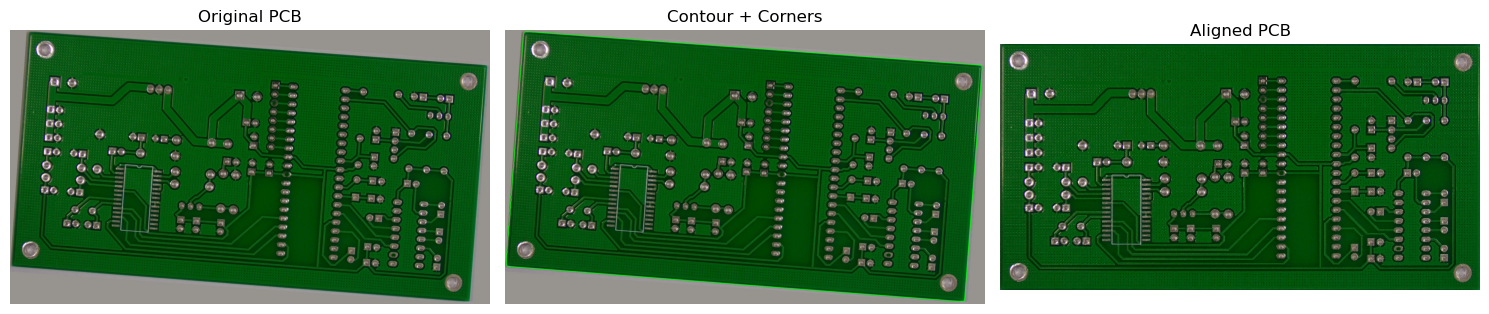

In [64]:
panels = [
    (cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB), "Original PCB"),
    (cv2.cvtColor(contour_demo, cv2.COLOR_BGR2RGB), "Contour + Corners"),
]
if sample_aligned is not None:
    panels.append((cv2.cvtColor(sample_aligned, cv2.COLOR_BGR2RGB), "Aligned PCB"))
else:
    panels.append((None, "Aligned PCB"))

plt.figure(figsize=(15, 5))
for i, (img, title) in enumerate(panels):
    plt.subplot(1, 3, i + 1)
    if img is not None:
        plt.imshow(img)
    else:
        plt.text(0.5, 0.5, "No 4-corner\nboundary found", ha="center", va="center")
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()


## Core Alignment Function

In [ ]:
# align_image comes from image_pipeline (Otsu corners -> aspect-preserving warp).
# Returns the aligned array, or None if the board is not found.
print("Align function loaded successfully! USE_GRAYSCALE =", USE_GRAYSCALE)


Align function loaded successfully! USE_GRAYSCALE = False


## Batch Alignment & Save

In [65]:
SAVE_OUTPUT = False  # Student 2 keeps results in memory; Student 3 saves at the end.

# aligned_results: cls -> {filename: aligned array}  (nothing written to disk)
aligned_results = {}
failed_count = 0

for cls, image_path in images:
    filename = os.path.basename(image_path)
    # FIX: process_from_folder() always looked inside Preprocessed_Dataset. With
    # USE_RAW_ROTATION=True the class folders are named "<Class>_rotation", so every
    # lookup missed and the whole batch silently reported "not aligned".
    # align_from_source() reads the file that was actually indexed, and runs
    # Student 1's preprocessing first when the source is raw.
    aligned_image = align_from_source(image_path, raw=USE_RAW_ROTATION)
    if aligned_image is None:
        failed_count += 1
        continue
    aligned_results.setdefault(cls, {})[filename] = aligned_image
    if SAVE_OUTPUT:  # optional inspection copy
        class_output = os.path.join(output_folder, cls)
        os.makedirs(class_output, exist_ok=True)
        cv2.imwrite(os.path.join(class_output, filename), aligned_image)

aligned_count = sum(len(v) for v in aligned_results.values())
skipped_count = len(images) - aligned_count

print("Alignment & Calibration Completed (in-memory, source=" + input_folder + ")!")
print(f"aligned: {aligned_count} | failed: {failed_count}")


Alignment & Calibration Completed (in-memory, source=Preprocessed_Dataset)!


## Visual QA: Check Alignment Results

In [ ]:
SHOW_ALL_RESULTS = True  # Toggle: True displays every aligned image (slow for large datasets), False shows 3 examples

display_list = [
    (cls, filename, array)
    for cls, files in aligned_results.items()
    for filename, array in files.items()
]
if not SHOW_ALL_RESULTS:
    display_list = display_list[:3]

cols = 4
rows = max(1, (len(display_list) + cols - 1) // cols)

plt.figure(figsize=(4 * cols, 4 * rows))

for i, (cls, filename, aligned_display) in enumerate(display_list):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(cv2.cvtColor(aligned_display, cv2.COLOR_BGR2RGB))
    plt.title(filename, fontsize=7)
    plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Displayed {len(display_list)} of {aligned_count} aligned images.")


## Display Before & After

Original Path: ../PCB_DATASET/rotation\Missing_hole_rotation\01_missing_hole_01.jpg


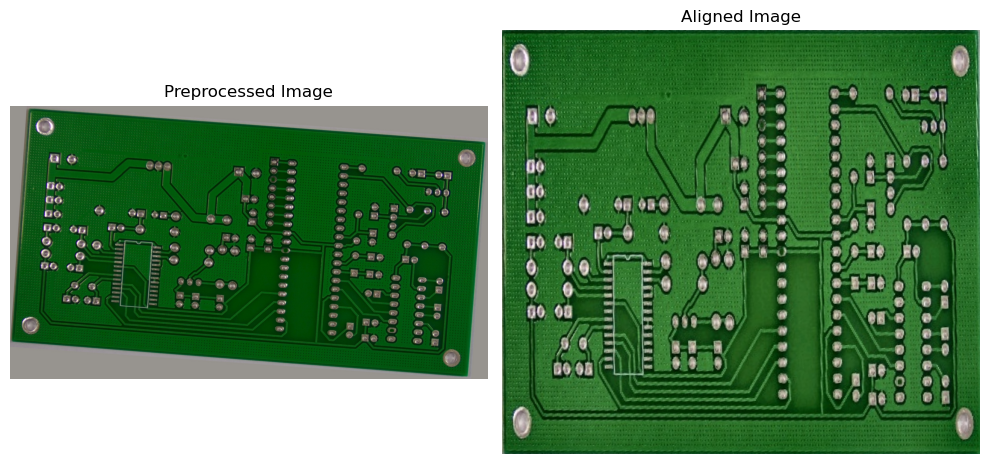

In [46]:
print("Original Path:", sample_path)

sample_filename = os.path.basename(sample_path)
aligned_display = aligned_results.get(sample_cls, {}).get(sample_filename)

if aligned_display is not None:
    original_display = cv2.imread(sample_path)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original_display, cv2.COLOR_BGR2RGB))
    plt.title("Preprocessed Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(aligned_display, cv2.COLOR_BGR2RGB))
    plt.title("Aligned Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Sample image was not aligned (board not found).")


## Summary

In [66]:
print("========== Calibrated Dataset Summary (in-memory) ==========")

for cls in classes:
    count = len(aligned_results.get(cls, {}))
    print(f"{cls}: {count} images")

print("--------------------------------------------------")
print("Source         : Preprocessed_Dataset (Student 1 output)")
print("Total Images   :", len(images))
print("Aligned (in-memory):", aligned_count)
print("Skipped        :", skipped_count)
print("Failed to read :", failed_count)
print("Skip rate      :", f"{skipped_count / len(images) * 100:.1f}%" if images else "n/a")
print("Saved to disk  :", SAVE_OUTPUT, "(Student 3 saves at the final step)")


========== Calibrated Dataset Summary (in-memory) ==========
Missing_hole_rotation: 115 images
Mouse_bite_rotation: 115 images
Open_circuit_rotation: 116 images
Short_rotation: 116 images
Spurious_copper_rotation: 116 images
Spur_rotation: 115 images
--------------------------------------------------
Source         : Preprocessed_Dataset (Student 1 output)
Total Images   : 693
Aligned (in-memory): 693
Skipped        : 0
Failed to read : 0
Skip rate      : 0.0%
Saved to disk  : False (Student 3 saves at the final step)


In [45]:
## VERIFY: Aligned output dimensions (aspect ratio preserved, in-memory)

from collections import Counter

dims = Counter()
samples = []
for cls, files in aligned_results.items():
    for filename, img in files.items():
        h, w = img.shape[:2]
        dims[(w, h)] += 1
        if len(samples) < 6:
            samples.append((filename, w, h))

print("Unique output sizes:", len(dims))
for (w, h), n in dims.most_common(10):
    print(f"  {w}x{h}: {n} images  (aspect {w/h:.2f})")
print()
print("Sample outputs:")
for name, w, h in samples:
    print(f"  {name:24s} {w}x{h}  aspect {w/h:.2f}")


Unique output sizes: 95
  640x637: 32 images  (aspect 1.00)
  640x624: 22 images  (aspect 1.03)
  640x636: 22 images  (aspect 1.01)
  618x640: 20 images  (aspect 0.97)
  640x606: 17 images  (aspect 1.06)
  640x596: 16 images  (aspect 1.07)
  640x630: 16 images  (aspect 1.02)
  640x621: 16 images  (aspect 1.03)
  640x633: 15 images  (aspect 1.01)
  640x617: 14 images  (aspect 1.04)

Sample outputs:
  01_missing_hole_01.jpg   640x568  aspect 1.13
  01_missing_hole_02.jpg   640x593  aspect 1.08
  01_missing_hole_03.jpg   640x555  aspect 1.15
  01_missing_hole_04.jpg   640x567  aspect 1.13
  01_missing_hole_05.jpg   640x555  aspect 1.15
  01_missing_hole_06.jpg   640x508  aspect 1.26


## In-Memory Pipeline (for Student 3)

Flow (all in memory, nothing written to disk):

**Student 3 → Student 2 → Student 1 → Student 3**

Student 2 calls Student 1's ACTUAL three functions, accepts the three kinds of
data Student 1 returns, applies the perspective transform, and returns the
aligned result to Student 3. Student 3 then runs defect detection on the
picture Student 2 returned.

| Student 1 returns | Student 2 accepts via | Student 3 receives |
|---|---|---|
| `preprocess_image(img)` → array | `student2_from_student1_array(...)` | aligned array |
| `process_image_from_bytes(bytes)` → JPEG bytes | `student2_from_student1_bytes(...)` | aligned array |
| `process_full_video_backend(bytes)` → video | `student2_from_student1_video(...)` | aligned video bytes |

Only Student 3 saves files (`save_aligned`).


E1) S1 preprocess_image        -> S2 -> S3 aligned array : (328, 640, 3)
E2) S1 process_image_from_bytes -> S2 -> S3 aligned array : (328, 640, 3)
E3) S1 process_full_video_backend -> S2 -> S3 aligned video : 258 bytes


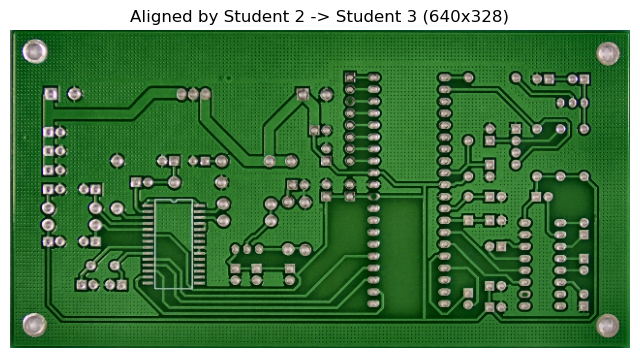

In [67]:
# Student 2 receives Student 1's THREE returned data kinds, aligns them,
# and returns the result to Student 3 (all in memory).
import tempfile

demo_cls = "Missing_hole_rotation"
demo_file = "01_missing_hole_01.jpg"
img_path = os.path.join(input_folder, demo_cls, demo_file)   # raw image Student 1 would read
raw = cv2.imread(img_path)

# E1) Student 1's array output (`preprocess_image`) -> Student 2 perspective -> aligned array
s3_array = student2_from_student1_array(raw)
print("E1) S1 preprocess_image        -> S2 -> S3 aligned array :",
      None if s3_array is None else s3_array.shape)

# E2) Student 1's bytes output (`process_image_from_bytes`) -> Student 2 -> aligned array
with open(img_path, "rb") as f:
    raw_bytes = f.read()
s3_array_bytes = student2_from_student1_bytes(raw_bytes)
print("E2) S1 process_image_from_bytes -> S2 -> S3 aligned array :",
      None if s3_array_bytes is None else s3_array_bytes.shape)

# E3) Student 1's video output (`process_full_video_backend`) -> Student 2 -> aligned video bytes
tmp_video = os.path.join(tempfile.gettempdir(), "demo_input.mp4")
vw = cv2.VideoWriter(tmp_video, cv2.VideoWriter_fourcc(*"mp4v"), 5, (320, 240))
for _ in range(5):
    vw.write(cv2.resize(raw, (320, 240)))
vw.release()
with open(tmp_video, "rb") as f:
    video_bytes = f.read()
s3_video = student2_from_student1_video(video_bytes)
print("E3) S1 process_full_video_backend -> S2 -> S3 aligned video :",
      None if s3_video is None else f"{len(s3_video)} bytes")
if os.path.exists(tmp_video):
    os.remove(tmp_video)

# Show the aligned picture (what Student 3 will run detection on)
if s3_array is not None:
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(s3_array, cv2.COLOR_BGR2RGB))
    plt.title(f"Aligned by Student 2 -> Student 3 ({s3_array.shape[1]}x{s3_array.shape[0]})")
    plt.axis("off")
    plt.show()
